In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve,GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

In [2]:
df = pd.read_csv("ames_cleaned.csv")

In [3]:
df.head()

,Lot Frontage,Lot Area,Lot Shape,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Mo Sold_3,Mo Sold_4,Mo Sold_5,Mo Sold_6,Mo Sold_7,Mo Sold_8,Mo Sold_9,Mo Sold_10,Mo Sold_11,Mo Sold_12
0,141.0,31770,3,1,6,5,1960,1960,112.0,3,...,0,0,1,0,0,0,0,0,0,0
1,80.0,11622,4,1,5,6,1961,1961,0.0,3,...,0,0,0,1,0,0,0,0,0,0
2,81.0,14267,3,1,6,6,1958,1958,108.0,3,...,0,0,0,1,0,0,0,0,0,0
3,93.0,11160,4,1,7,5,1968,1968,0.0,4,...,0,1,0,0,0,0,0,0,0,0
4,74.0,13830,3,1,5,5,1997,1998,0.0,3,...,1,0,0,0,0,0,0,0,0,0


In [4]:
# Since i am trying to predict the sale price , i sepeare X and Y accordingly

In [5]:
X = df.drop(columns=['SalePrice']) ## includes everything except the target (Input variables)
y = df['SalePrice'] # output or the target

In [6]:
df.shape

(2927, 237)

In [7]:
y.describe()

count    2927.000000
mean       12.020918
std         0.407783
min         9.456419
25%        11.771444
50%        11.982935
75%        12.271397
max        13.534474
Name: SalePrice, dtype: float64

## Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape[0]

2341

In [10]:
X_test.shape[0]

586

## Training a decision Tree

In [11]:
dt = DecisionTreeRegressor(
    max_depth=5, # max level is 5
    min_samples_split=20,  # atleast 20 data points are needed to split a node 
    min_samples_leaf=10, # min samples required in a leaf node 
    random_state=42 ## same data used across training 
)

In [12]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

In [13]:
y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

## Eval Scores

In [14]:
mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train,y_pred_train)

In [15]:
mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

In [16]:
cv_scores  = cross_val_score( ## different train test split is used 
    DecisionTreeRegressor(max_depth=8, min_samples_split=10,
                          min_samples_leaf=10, ccp_alpha=0.0, random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)

In [17]:
print("\nMODEL SCORES")
print(f"  Train  | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f} | R²: {r2_train:.4f} | MSE :{mse_train:.4f}")
print(f"  Test   | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f} | R²: {r2_test:.4f} | MSE :{mse_test:.4f}")
print(f"  CV R²  | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")



MODEL SCORES
  Train  | MAE: 0.1226 | RMSE: 0.1681 | R²: 0.8265 | MSE :0.0283
  Test   | MAE: 0.1366 | RMSE: 0.1847 | R²: 0.8100 | MSE :0.0341
  CV R²  | Mean: 0.7935 | Std: 0.0068


## Imprpving Scores

In [18]:
baseline = DecisionTreeRegressor(
    max_depth=5, min_samples_split=20,
    min_samples_leaf=10, random_state=42
)

In [19]:
baseline.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

In [20]:
base_r2_train = r2_score(y_train, baseline.predict(X_train))
base_r2_test  = r2_score(y_test,  baseline.predict(X_test))
base_mae      = mean_absolute_error(y_test, baseline.predict(X_test))
base_rmse     = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test)))

In [21]:
print(f"  Train R²  : {base_r2_train:.4f}")
print(f"  Test  R²  : {base_r2_test:.4f}")
print(f"  Test  MAE : {base_mae:.4f}")
print(f"  Test  RMSE: {base_rmse:.4f}")

  Train R²  : 0.8265
  Test  R²  : 0.8100
  Test  MAE : 0.1366
  Test  RMSE: 0.1847


## Hyperparam Tuning

In [22]:
param_grid = {
    'max_depth'        : [4, 5, 6, 7, 8],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf' : [5, 10, 15, 20],
    'ccp_alpha'        : [0.0, 0.001, 0.005, 0.01]
}

In [23]:
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid, # grid search cv template i created before 
    cv=5, # model trained and tested 5 times
    scoring='r2', # uses r2 to find out the scores
    n_jobs=-1, # using all cpu cores 
    verbose=1 ## we r seeing the progress along with the tuning
)

In [24]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
                         'max_depth': [4, 5, 6, 7, 8],
                         'min_samples_leaf': [5, 10, 15, 20],
                         'min_samples_split': [10, 20, 30, 50]},
             scoring='r2', verbose=1)

In [25]:
print("\n GRIDSEARCH RESULTS ")
print("Best Parameters :", grid_search.best_params_)
print("Best CV R²      :", round(grid_search.best_score_, 4))


 GRIDSEARCH RESULTS 
Best Parameters : {'ccp_alpha': 0.0, 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best CV R²      : 0.7935


## Best Tuned model

In [26]:
best_dt = grid_search.best_estimator_
 
y_pred_train = best_dt.predict(X_train)
y_pred_test  = best_dt.predict(X_test)

In [27]:
mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

In [28]:
mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

In [29]:
print("\nTUNED MODEL SCORES ")
print(f"  Train  | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f} | R²: {r2_train:.4f}")
print(f"  Test   | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f} | R²: {r2_test:.4f}")
print(f"  CV R²  | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
print(f"\n  Improvement over baseline:")
print(f"    R² : {base_r2_test:.4f} → {r2_test:.4f}  (+{r2_test - base_r2_test:.4f})")
print(f"    MAE: {base_mae:.4f} → {mae_test:.4f}  ({base_mae - mae_test:+.4f})")


TUNED MODEL SCORES 
  Train  | MAE: 0.0915 | RMSE: 0.1302 | R²: 0.8959
  Test   | MAE: 0.1243 | RMSE: 0.1735 | R²: 0.8324
  CV R²  | Mean: 0.7935 | Std: 0.0068

  Improvement over baseline:
    R² : 0.8100 → 0.8324  (+0.0223)
    MAE: 0.1366 → 0.1243  (+0.0124)


In [30]:
residuals  = y_test  - y_pred_test
print("Residuals (Test Set) Summary:")
print(f"  Mean   : {residuals.mean():.4f}")
print(f"  Std Dev: {residuals.std():.4f}")
print(f"  Min    : {residuals.min():.4f}")
print(f"  Max    : {residuals.max():.4f}")


Residuals (Test Set) Summary:
  Mean   : -0.0014
  Std Dev: 0.1736
  Min    : -0.8774
  Max    : 0.8433


In [31]:
# Step 1: Set threshold using standard deviation
threshold = 3 * np.std(residuals)

# Step 2: Flag anomalies
anomalies = np.abs(residuals) > threshold

# Step 3: Print summary
print(f"Threshold: {threshold:.2f}")
print(f"Total anomalies detected: {anomalies.sum()}")
print(f"Anomaly percentage: {anomalies.mean() * 100:.2f}%")


Threshold: 0.52
Total anomalies detected: 7
Anomaly percentage: 1.19%


In [32]:
# viewing anolmoly points
# Get the anomaly indices from test set
anomaly_indices = y_test.index[anomalies]

# Create a dataframe showing anomaly details
anomaly_df = X_test.loc[anomaly_indices].copy()
anomaly_df['Actual_SalePrice']    = y_test.loc[anomaly_indices].values
anomaly_df['Predicted_SalePrice'] = y_pred_test[anomalies]
anomaly_df['Residual']            = residuals[anomalies]

print(f"Total Anomalies: {len(anomaly_df)}")
anomaly_df

Total Anomalies: 7


,Lot Frontage,Lot Area,Lot Shape,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Mo Sold_6,Mo Sold_7,Mo Sold_8,Mo Sold_9,Mo Sold_10,Mo Sold_11,Mo Sold_12,Actual_SalePrice,Predicted_SalePrice,Residual
2858,80.0,11600,4,1,4,5,1922,1950,0.0,3,...,0,1,0,0,0,0,0,11.831386,10.988119,0.843267
695,52.0,5720,4,1,5,6,1941,1950,0.0,3,...,0,0,1,0,0,0,0,11.104972,11.774978,-0.670006
2658,63.0,5000,4,1,5,4,1900,1950,0.0,3,...,0,0,0,0,0,0,0,11.277216,11.964609,-0.687393
940,50.0,8660,4,1,5,6,1900,1993,0.0,3,...,0,0,0,0,0,0,1,11.719948,12.457580,-0.737632
2044,138.0,18030,3,1,5,6,1946,1994,0.0,3,...,0,0,0,0,0,0,0,12.208575,11.670037,0.538537
790,68.0,9571,4,1,5,3,1958,1958,0.0,3,...,1,0,0,0,0,0,0,11.002117,11.879496,-0.877379
1289,60.0,4800,4,1,5,4,1940,1950,0.0,3,...,0,0,1,0,0,0,0,11.066654,11.688332,-0.621678


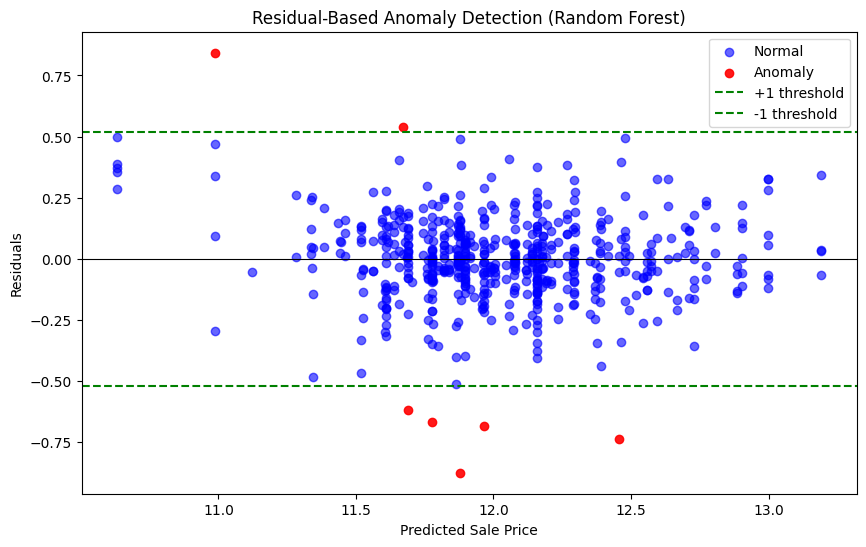

In [33]:
# visulalization ko lai chai yo # Step 4: Visualize residuals with anomalies highlighted
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test[~anomalies], residuals[~anomalies], 
            alpha=0.6, label='Normal', color='blue')
plt.scatter(y_pred_test[anomalies], residuals[anomalies], 
            alpha=0.9, label='Anomaly', color='red')
plt.axhline(y=threshold, color='green', linestyle='--', label=f'+{threshold:.0f} threshold')
plt.axhline(y=-threshold, color='green', linestyle='--', label=f'-{threshold:.0f} threshold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual-Based Anomaly Detection (Random Forest)")
plt.legend()
plt.show()

In [34]:
svr_idx = [765, 1557, 1641, 1771, 727, 742, 1014, 790, 1536, 432, 1321, 1766, 1027]

rf_idx = [423, 1537, 436, 44, 1771, 2095, 433, 432, 1766, 2096, 456]

dt_idx = [2858, 695, 2658, 940, 2044, 790, 1289]

lr_idx = [433, 2233, 1356, 2114, 2567, 2226, 1954, 108, 2727, 790,
          2323, 942, 2858, 1338, 695, 767, 210, 1220, 742, 1289]

In [35]:
from collections import Counter

all_anomalies = svr_idx + rf_idx + lr_idx + dt_idx

counts = Counter(all_anomalies)

robust_anomalies = [idx for idx, c in counts.items() if c >= 2]

print("Robust anomalies:", robust_anomalies)

for idx in robust_anomalies:
    print(idx, "detected by", counts[idx], "models")

Robust anomalies: [1771, 742, 790, 432, 1766, 433, 2858, 695, 1289]
1771 detected by 2 models
742 detected by 2 models
790 detected by 3 models
432 detected by 2 models
1766 detected by 2 models
433 detected by 2 models
2858 detected by 2 models
695 detected by 2 models
1289 detected by 2 models


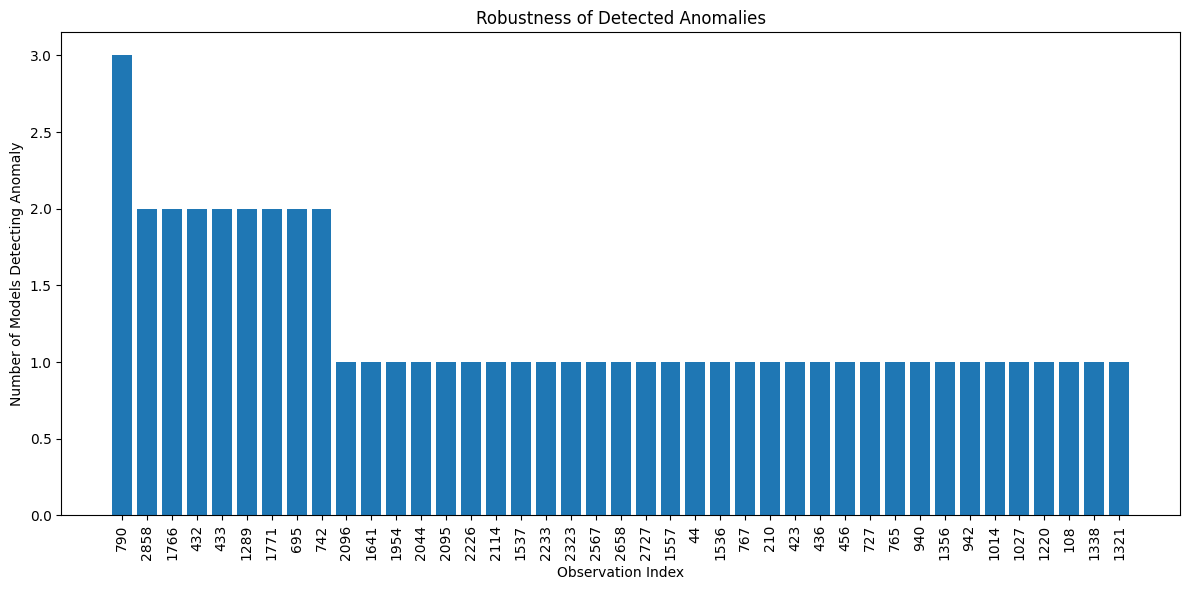

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

all_idx = sorted(set(all_anomalies))

agreement = pd.DataFrame(index=all_idx)

agreement['SVR'] = [1 if i in svr_idx else 0 for i in all_idx]
agreement['RF'] = [1 if i in rf_idx else 0 for i in all_idx]
agreement['LR'] = [1 if i in lr_idx else 0 for i in all_idx]
agreement['DT'] = [1 if i in dt_idx else 0 for i in all_idx]

agreement['Total Models'] = agreement.sum(axis=1)

agreement = agreement.sort_values(
    'Total Models',
    ascending=False
)

plt.figure(figsize=(12,6))
plt.bar(
    agreement.index.astype(str),
    agreement['Total Models']
)

plt.xticks(rotation=90)
plt.ylabel("Number of Models Detecting Anomaly")
plt.xlabel("Observation Index")
plt.title("Robustness of Detected Anomalies")
plt.tight_layout()
plt.show()

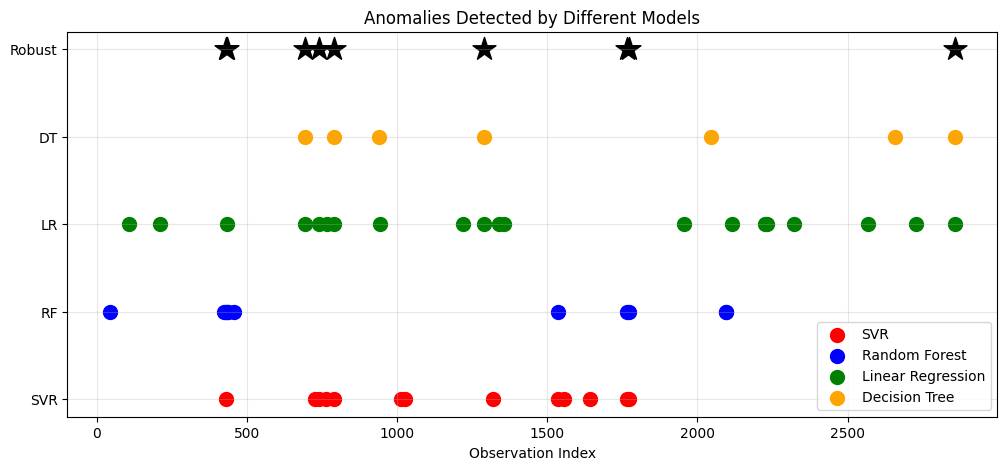

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.scatter(svr_idx,
            [1]*len(svr_idx),
            color='red',
            s=100,
            label='SVR')

plt.scatter(rf_idx,
            [2]*len(rf_idx),
            color='blue',
            s=100,
            label='Random Forest')

plt.scatter(lr_idx,
            [3]*len(lr_idx),
            color='green',
            s=100,
            label='Linear Regression')

plt.scatter(dt_idx,
            [4]*len(dt_idx),
            color='orange',
            s=100,
            label='Decision Tree')

for idx in robust_anomalies:
    plt.scatter(idx,
                5,
                color='black',
                marker='*',
                s=300)

plt.yticks(
    [1,2,3,4,5],
    ['SVR','RF','LR','DT','Robust']
)

plt.xlabel("Observation Index")
plt.title("Anomalies Detected by Different Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
all_indices = set(svr_idx + rf_idx + lr_idx + dt_idx)

results = []

for idx in sorted(all_indices):
    models = []

    if idx in svr_idx:
        models.append("SVR")

    if idx in rf_idx:
        models.append("Random Forest")

    if idx in lr_idx:
        models.append("Linear Regression")

    if idx in dt_idx:
        models.append("Decision Tree")

    results.append({
        "Index": idx,
        "No. of Models": len(models),
        "Models": ", ".join(models)
    })

agreement_df = pd.DataFrame(results)

In [39]:
agreement_df

,Index,No. of Models,Models
0,44,1,Random Forest
1,108,1,Linear Regression
2,210,1,Linear Regression
3,423,1,Random Forest
4,432,2,"SVR, Random Forest"
5,433,2,"Random Forest, Linear Regression"
6,436,1,Random Forest
7,456,1,Random Forest
8,695,2,"Linear Regression, Decision Tree"
9,727,1,SVR


In [40]:
import pandas as pd

# find anomalies detected by 2 or more models
all_indices = set(svr_idx) | set(rf_idx) | set(lr_idx) | set(dt_idx)

rows = []
for idx in all_indices:
    models = []
    if idx in svr_idx:
        models.append("SVR")
    if idx in rf_idx:
        models.append("Random Forest")
    if idx in lr_idx:
        models.append("Linear Regression")
    if idx in dt_idx:
        models.append("Decision Tree")
    
    # only keep if detected by 2 or more models
    if len(models) >= 2:
        rows.append({
            "Index": idx,
            "Detected By": len(models),
            "Models": ", ".join(models)
        })

robust_df = pd.DataFrame(rows)
display(robust_df.sort_values("Detected By", ascending=False).reset_index(drop=True))

,Index,Detected By,Models
0,790,3,"SVR, Linear Regression, Decision Tree"
1,1289,2,"Linear Regression, Decision Tree"
2,2858,2,"Linear Regression, Decision Tree"
3,432,2,"SVR, Random Forest"
4,433,2,"Random Forest, Linear Regression"
5,695,2,"Linear Regression, Decision Tree"
6,742,2,"SVR, Linear Regression"
7,1766,2,"SVR, Random Forest"
8,1771,2,"SVR, Random Forest"


In [41]:
results_rf = pd.DataFrame({
    'House_Index': range(len(y_test)),
    'Actual': np.expm1(y_test),
    'Predicted': np.expm1(y_pred_test),
    'Residual': np.expm1(y_test) - np.expm1(y_pred_test),
    'Model': 'Decision Tree'
})
results_rf.to_csv('results_decision_forest.csv', index=False)

In [42]:
import os
print(os.getcwd())

/Users/samiksha/dashboard


In [43]:
print(df['SalePrice'].iloc[0])  # what is the first value?
print(df.shape)                  # how many rows and columns?

12.278397958261774
(2927, 237)


In [45]:
print("R2:", r2_score(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("MAE:", mean_absolute_error(y_test, y_pred_test))

R2: 0.8323995542544076
RMSE: 0.17350657451314258
MAE: 0.12426754926438965


In [46]:
print("SVR anomalies:", list(svr_idx))
print("RF anomalies:", list(rf_idx))
print("LR anomalies:", list(lr_idx))
print("DT anomalies:", list(dt_idx))

SVR anomalies: [765, 1557, 1641, 1771, 727, 742, 1014, 790, 1536, 432, 1321, 1766, 1027]
RF anomalies: [423, 1537, 436, 44, 1771, 2095, 433, 432, 1766, 2096, 456]
LR anomalies: [433, 2233, 1356, 2114, 2567, 2226, 1954, 108, 2727, 790, 2323, 942, 2858, 1338, 695, 767, 210, 1220, 742, 1289]
DT anomalies: [2858, 695, 2658, 940, 2044, 790, 1289]
